In [1]:
# does stuff like distribution anaysis for each cluster. Look at typical distribution of each cluster. Overlap mean distribution, plot each of the 4 variables for all 12 clusters, etc.

In [2]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter1d
from minisom import MiniSom
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from sklearn.metrics import silhouette_score
import matplotlib.gridspec as gridspec

In [3]:
weather = xr.open_dataset('data/raw_data/heights.nc')

In [4]:
z = weather['z'].load()/9.81 /10  # (time, lat, lon)

z = z.squeeze('pressure_level')

# day-of-year climatology
climo = z.groupby('valid_time.dayofyear').mean('valid_time')

# smooth climatology (cyclic!)
climo_vals = climo.values  # (dayofyear, lat, lon)

climo_smooth = uniform_filter1d(
    climo_vals,
    size=15,
    axis=0,
    mode='wrap'
)

climo = xr.DataArray(
    climo_smooth,
    dims=climo.dims,
    coords=climo.coords
)

# anomalies
doy = z['valid_time'].dt.dayofyear
anom = z - climo.sel(dayofyear=doy)

In [5]:
# detrending to remove climate signal
p = anom.polyfit(dim='valid_time', deg=1)
trend = xr.polyval(anom['valid_time'], p.polyfit_coefficients)

anom_dt = anom - trend

In [6]:
missing_dates = [
    '200204250000', '200208300000', '200304150000', '200304160000',
    '200306250000', '200307270000', '200307280000', '200312280000',
    '200404140000', '200408090000', '200905280000', '201105210000',
    '202005240000', '200510240000'
]
missing_dt = pd.to_datetime(missing_dates, format='%Y%m%d%H%M')

In [7]:
# selection of desired days
pph = xr.open_dataset('data/raw_data/labelled_pph.nc')
pph_time = pd.to_datetime(pph['time'].values, format='%Y%m%d%H%M')

cats = ['SLGT', 'ENH', 'MDT', 'HIGH']
mask = np.isin(pph['MAX_CAT'].values, cats) & (pph_time> '2002-04-01') & (pph_time < '2020-01-01') & ~np.isin(pph_time, missing_dt)

times_shifted = pph_time[mask] + np.timedelta64(1, 'D')

anom_dt = anom_dt.sel(valid_time=times_shifted)
anom = anom.sel(valid_time=times_shifted)

In [8]:
# latitude weight and prep
weights = np.sqrt(np.cos(np.deg2rad(anom_dt['latitude'])))
anom_w = anom_dt * weights

X = anom_w.stack(space=('latitude','longitude')).transpose('valid_time','space')

In [9]:
# do PCA
pca = PCA(n_components=10)
PCs = pca.fit_transform(X)

In [10]:
components = pca.components_

# Get original lat/lon
lats = anom_w.latitude
lons = anom_w.longitude

# Reshape into maps
scaled = pca.components_ * np.sqrt(pca.explained_variance_)[:, None]

# convert to DataArray with the same stacked coordinate
eofs = xr.DataArray(
    scaled,
    dims=('mode', 'space'),
    coords={'space': X.space}
).unstack('space')   # -> (mode, latitude, longitude)

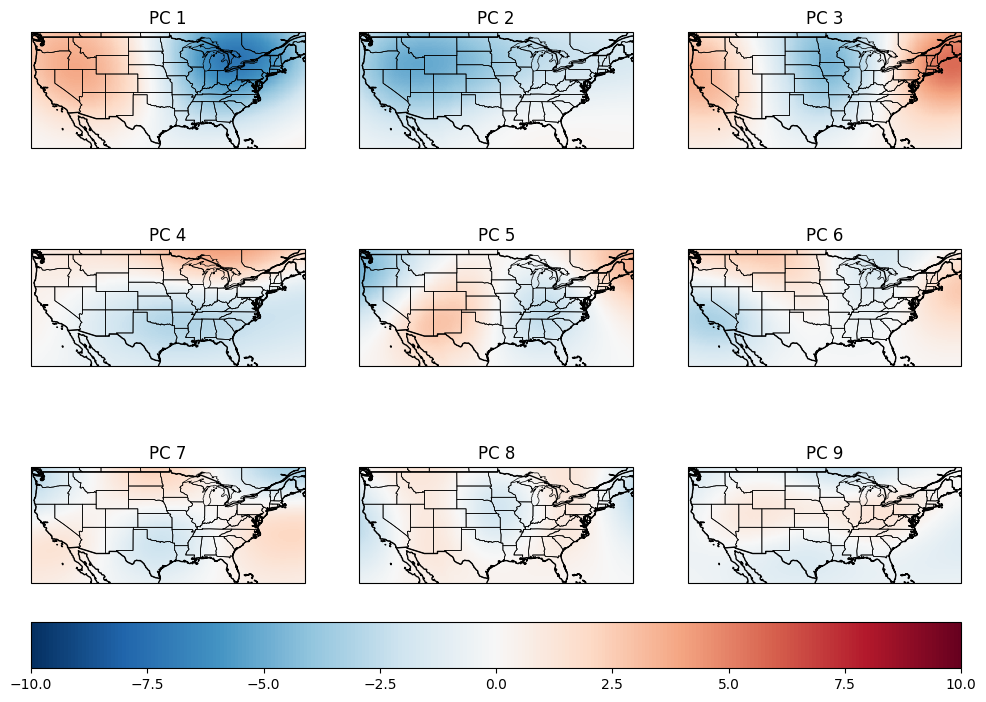

In [11]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i, ax in enumerate(axes.flat):
    eof = eofs[i]

    im = ax.pcolormesh(
        lons, lats, eof,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin = -10,
        vmax = 10
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    ax.set_title(f'PC {i+1}')

# colorbar (shared)
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.05)

plt.show()

In [12]:
# do som
size_1 = 3
size_2 = 3

som = MiniSom(size_1, size_2, PCs.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train(PCs, 100000)

In [13]:
def composite(labels):
    # convert 2D SOM indices -> single 1D cluster id
    if labels.ndim == 2:
        # make each (i,j) pair a unique integer
        ncols = labels[:,1].max() + 1
        labels_1d = labels[:,0] * ncols + labels[:,1]
    else:
        labels_1d = labels

    comps = []
    for k in np.unique(labels_1d):
        idx = np.where(labels_1d == k)[0]
        comps.append(anom.isel(valid_time=idx).mean('valid_time'))

    return xr.concat(comps, dim='cluster')

def som_labels(som, X):
    winners = np.array([som.winner(x) for x in X])
    # convert (i,j) -> single cluster id
    return winners[:,0] * som._weights.shape[1] + winners[:,1]

In [14]:
outlooks = xr.open_dataset('data/raw_data/grid_outlooks.nc')
reports = xr.open_dataset('data/raw_data/grid_reports.nc')

In [15]:
contingencies = xr.load_dataset('data/raw_data/binary_contingency_regions.nc')

In [16]:
labels_cluster = som_labels(som, PCs)
score = silhouette_score(PCs, labels_cluster)

comp_som = composite(labels_cluster)
n_clusters = comp_som.sizes['cluster']

cluster_data = {}

counts = np.bincount(labels_cluster)



color_dict = {
    'Wind': 'blue',
    'Hail': 'green',
    'Tornado': 'red'
}

for i in range(n_clusters):

    idx = np.where(labels_cluster == i)[0]
    times_cluster = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')
    times_str = (times_cluster.dt.strftime('%Y%m%d') + '0000').values

    # --- composites
    field = comp_som.isel(cluster=i)

    ol = outlooks.sel(time=times_str)
    rp = reports.sel(time=times_str)

    ol_mean = ol.mean('time')
    rp_mean = rp.mean('time')

    lat = outlooks['lat']
    lon = outlooks['lon']

    def centroid_and_size(weight, power=2):
        w = weight**power
        wsum = w.sum()
        clat = (w * lat).sum() / wsum
        clon = (w * lon).sum() / wsum
        return float(clon), float(clat), float(weight.sum())

    # --- centroid markers
    centroids = []
    for w in [
        ol_mean['prob'].sel(outlook='Day 1 Wind'),
        rp_mean['bool'].sel(hazard='Wind'),
        ol_mean['prob'].sel(outlook='Day 1 Hail'),
        rp_mean['bool'].sel(hazard='Hail'),
        ol_mean['prob'].sel(outlook='Day 1 Tornado'),
        rp_mean['bool'].sel(hazard='Tornado'),
    ]:
        centroids.append(centroid_and_size(w))

    # --- seasonal rose
    months = times_cluster.dt.month.values
    month_counts = np.bincount(months-1, minlength=12)

    # --- shift compass means
    compass = {}
    for e_var, n_var in zip(
        ['E_SH_W_NUM','E_SH_H_NUM','E_SH_T_NUM'],
        ['N_SH_W_NUM','N_SH_H_NUM','N_SH_T_NUM']):
        e = pph[e_var].sel(time=times_str).mean().item()
        n = pph[n_var].sel(time=times_str).mean().item()
        compass[(e_var, n_var)] = (e, n)

    # --- skill points
    #skill = {}
    #for far_var, pod_var in zip(
    #    ['FAR_W_NUM','FAR_H_NUM','FAR_T_NUM'],
    #    ['POD_W_NUM','POD_H_NUM','POD_T_NUM']):
    #    x = (1 - pph[far_var].sel(time=times_str).mean()).item()
    #    y = pph[pod_var].sel(time=times_str).mean().item()
    #    skill[(far_var, pod_var)] = (x, y)

    pods = []
    fars = []
    labels_skill = []
    colors = []
    markers = []

    for hazard in ['Wind', 'Hail', 'Tornado']:
        c = contingencies.sel(time = times_str, hazard = hazard)
        pods.append(np.array([c['a'].values.sum()/(c['a'].values.sum() + c['c'].values.sum())]))
        fars.append(np.array([c['b'].values.sum()/(c['a'].values.sum() + c['b'].values.sum())]))
        labels_skill.append(hazard)
        colors.append(color_dict[hazard])
        markers.append('s')

    # --- table quantities
    max_cat_map = {'SLGT':2, 'ENH':3, 'MDT':4, 'HIGH':5}
    vals = np.array([max_cat_map[c] for c in pph.MAX_CAT.sel(time=times_str).values])
    avg_cat = np.nanmean(vals)

    def avg_max_prob(outlook_name):
        probs = ol['prob'].sel(outlook=outlook_name)
        return float(probs.max(('x','y')).mean())

    avg_wind = avg_max_prob('Day 1 Wind')
    avg_hail = avg_max_prob('Day 1 Hail')
    avg_tor  = avg_max_prob('Day 1 Tornado')

    cluster_data[i] = dict(
        field=field,
        count=counts[i],
        centroids=centroids,
        rose=month_counts,
        compass=compass,
        pods = pods,
        fars = fars,
        labels_skill = labels_skill,
        colors = colors,
        markers = markers,
        avg_cat=avg_cat,
        avg_wind=avg_wind,
        avg_hail=avg_hail,
        avg_tor=avg_tor,
    )

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


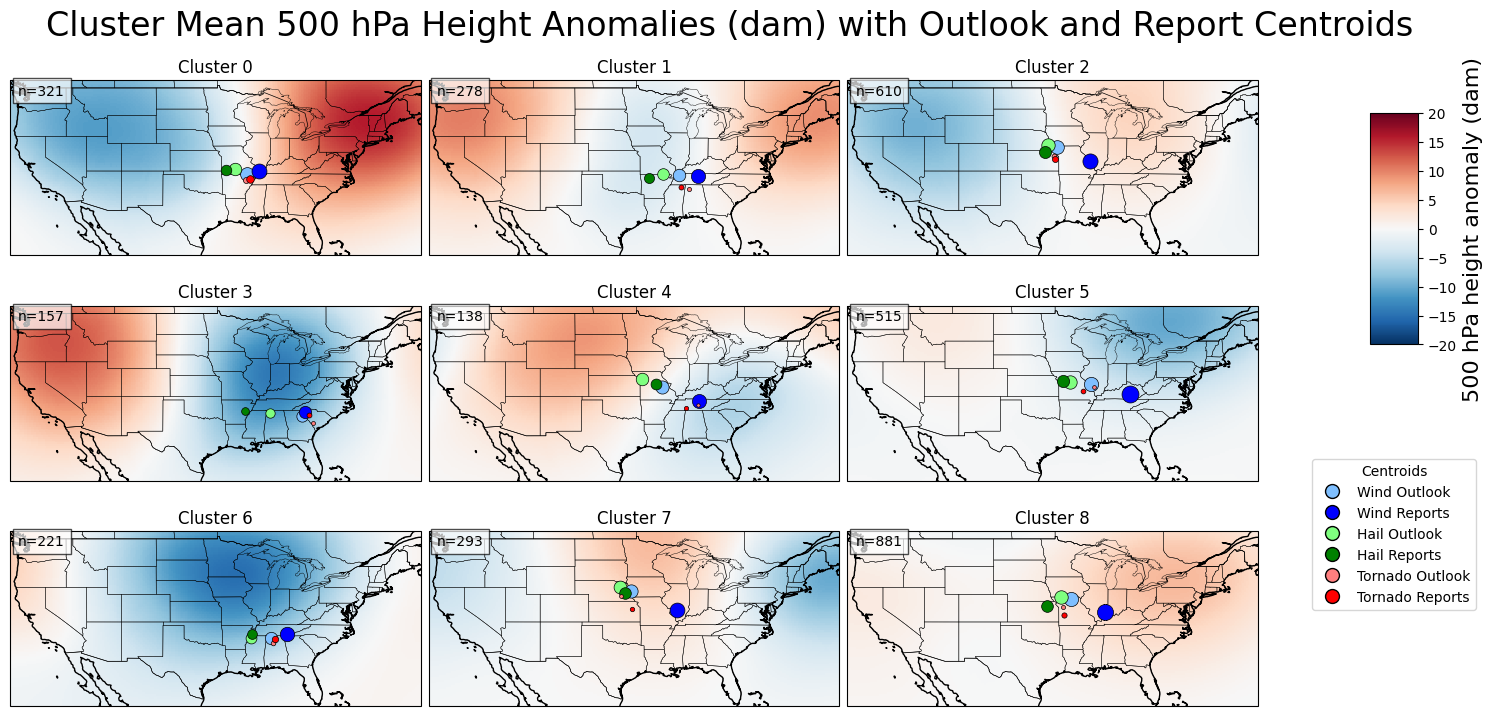

In [17]:
fig = plt.figure(figsize=(16, 8))

# --- main grid for maps (uses constrained layout) ---
gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.83, top=0.92, bottom=0.08,
    wspace=0.02, hspace=0.02
)

axes = []
for r in range(size_1):
    for c in range(size_2):
        ax = fig.add_subplot(gs_maps[r, c], projection=ccrs.PlateCarree())
        axes.append(ax)

# --- side column (independent of map layout) ---
gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle(
    'Cluster Mean 500 hPa Height Anomalies (dam) with Outlook and Report Centroids',
    fontsize=24
)


for i, ax in enumerate(axes[:n_clusters]):
    d = cluster_data[i]

    im = ax.pcolormesh(
        d['field']['longitude'],
        d['field']['latitude'],
        d['field'].values,
        cmap='RdBu_r', vmin=-20, vmax=20,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i}')
    ax.text(
        0.02, 0.98, f'n={d["count"]}',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7)
    )

    for (clon, clat, size), color in zip(
        d['centroids'],
        ['#7fbfff','blue','#7fff7f','green','#ff7f7f','red']
    ):
        ax.scatter(
            clon, clat, s=size*5, color=color,
            edgecolor='k', linewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=10
        )

# colorbar lives in its own gridspec column
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('500 hPa height anomaly (dam)', fontsize=16)


# --- legend proxies ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#7fbfff', markeredgecolor='k', markersize=10,
           label='Wind Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='k', markersize=10,
           label='Wind Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#7fff7f', markeredgecolor='k', markersize=10,
           label='Hail Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markeredgecolor='k', markersize=10,
           label='Hail Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#ff7f7f', markeredgecolor='k', markersize=10,
           label='Tornado Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markeredgecolor='k', markersize=10,
           label='Tornado Reports'),
]
# legend
lax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='Centroids'
)

plt.savefig('figs/clustering/composites.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig('figs/clustering/composites.png', dpi = 1000, bbox_inches='tight')
plt.show()

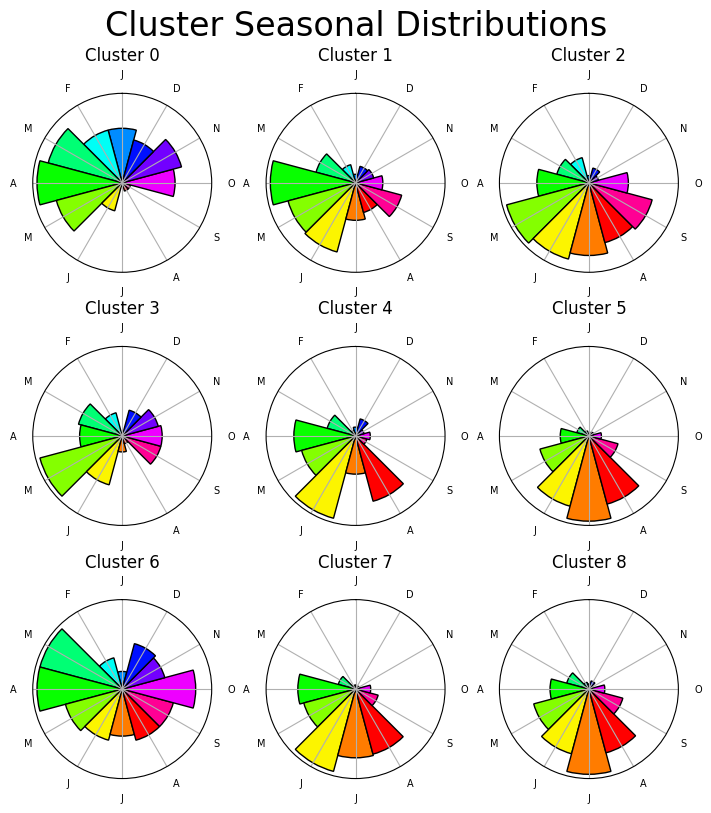

In [18]:
import matplotlib.cm as cm
fig, axes = plt.subplots(
    size_1, size_2,
    subplot_kw={'polar': True},
    figsize=(7, 8),
    constrained_layout=True
)

fig.suptitle('Cluster Seasonal Distributions', fontsize=24)

axes = axes.ravel()
angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
labels = np.array(['J','F','M','A','M','J','J','A','S','O','N','D'])

# Color mapping:
# start hue at September, then proceed backward through the year
start = 7  # September
month_order = (start - np.arange(12)) % 12
colors_by_month = cm.hsv(month_order / 12.0)

for i, ax in enumerate(axes[:n_clusters]):
    counts = cluster_data[i]['rose']

    # Polar orientation: January at top, CCW months
    ax.set_theta_zero_location('N')   # top
    ax.set_theta_direction(1)         # counterclockwise

    ax.bar(
        angles,
        counts,
        width=2*np.pi/12,
        color=colors_by_month,
        edgecolor='k'
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticks([])
    ax.set_title(f'Cluster {i}')

plt.savefig('figs/clustering/seasonal.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig('figs/clustering/seasonal.png', dpi = 1000, bbox_inches='tight')

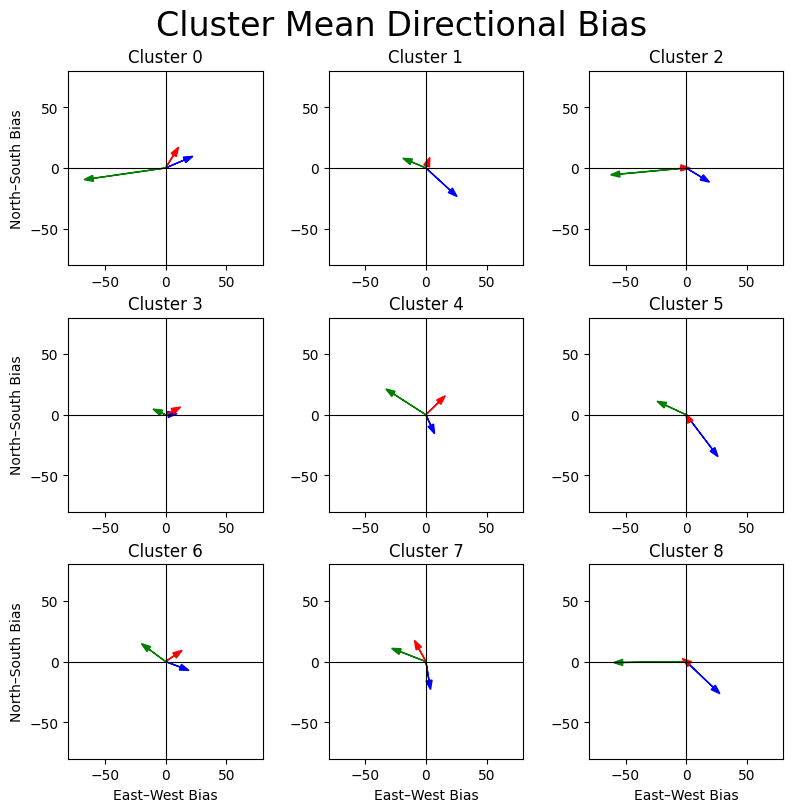

In [19]:
fig, axes = plt.subplots(
    size_1, size_2,
    figsize=(8, 8),
    constrained_layout=True
)
axes = axes.ravel()

fig.suptitle('Cluster Mean Directional Bias', fontsize=24)

scale = 1000

plot_width = 80

for i, ax in enumerate(axes[:n_clusters]):
    ax.set_aspect('equal')
    ax.set_xlim(-plot_width, plot_width)
    ax.set_ylim(-plot_width, plot_width)

    # Centered axes
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)

    for (e_var, n_var), color in zip(
        cluster_data[i]['compass'],
        ['blue', 'green', 'red']
    ):
        e, n = cluster_data[i]['compass'][(e_var, n_var)]
        ax.arrow(
            0, 0,
            e/scale, n/scale,
            color=color,
            width=0.03,
            length_includes_head=True,
            head_width=5
        )
    if i in [0, 3, 6]:
        ax.set_ylabel('North–South Bias')
    if i in [6, 7, 8]:
        ax.set_xlabel('East–West Bias')
    
    ax.set_title(f'Cluster {i}')

plt.savefig('figs/clustering/directional.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig('figs/clustering/directional.png', dpi = 1000, bbox_inches='tight')

In [20]:
# Adapted from https://gist.github.com/djgagne/64516e3ea268ec31fb34

def performance_diagram(pods, fars, obj_labels, colors, markers, filename = '', save = False, show = True, figsize=(9, 8), points = True, xlabel="Success Ratio (1-FAR)",
                        ylabel="Probability of Detection", ticks=np.arange(0, .6, 0.1), dpi=300, csi_cmap="Blues",
                        csi_label="Critical Success Index", title="Performance Diagram",
                        legend_params=dict(loc=4, fontsize=12, framealpha=1, frameon=True),
                        ax = None, show_cbar=False, show_legend=False, show_xlabel = False, show_ylabel = False):
    """
    Draws a performance diagram from a set of POD lists and FAR lists.
    :param pods: list or array of POD arrays.
    :param fars: list or array of FAR arrays.
    :param obj_labels: list or array of labels describing each DistributedROC object.
    :param colors: list of color strings
    :param markers: list of markers.
    :param filename: output filename.
    :param save: whether the figure will be saved
    :param show: whether the figure will be shown in the console
    :param figsize: tuple with size of the figure in inches.
    :param points: True if the plotted points should be separate, otherwise connected
    :param xlabel: Label for the x-axis
    :param ylabel: Label for the y-axis
    :param ticks: Array of ticks used for x and y axes
    :param dpi: DPI of the output image
    :param csi_cmap: Colormap used for the CSI contours
    :param csi_label: Label for the CSI colorbar
    :param ax: Axis object to plot the diagram
    :return:
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        own_fig = True
    else:
        fig = ax.figure  # Get figure from existing axis
        own_fig = False

    grid_ticks = np.arange(0, .51, 0.01)
    sr_g, pod_g = np.meshgrid(grid_ticks, grid_ticks)
    bias = pod_g / sr_g
    csi = 1.0 / (1.0 / sr_g + 1.0 / pod_g - 1.0)

    csi_contour = ax.contourf(sr_g, pod_g, csi, np.arange(.025, .325, 0.025), extend="max", cmap=csi_cmap)
    b_contour = ax.contour(sr_g, pod_g, bias, [.25, 0.5, 1, 2, 4], colors="k", linestyles="dashed")
    ax.clabel(b_contour, fmt="%1.2f", manual=[(0.1, 0.45), (0.2, 0.45), (0.35, 0.35), (.45, .2), (.45, .1)])
    for r, (pod, far) in enumerate(zip(pods, fars)):
        if points:
            ax.scatter(1 - far, pod, color=colors[r], label=obj_labels[r], s = 50)
        else:
            ax.plot(1 - far, pod, marker=markers[r], color=colors[r], label=obj_labels[r], markersize = 5, linewidth = 1)
            shift0 = .03
            shift1 = .03
            if r == 3:
                shift1 = 0
            ax.annotate('2002', xy = (1-far[1], pod[1]), xytext=(1-far[1]-shift1, pod[1]+shift0), arrowprops=dict(arrowstyle="->"))
            ax.annotate('2023', xy = (1-far[-1], pod[-1]), xytext=(1-far[-1]+shift0, pod[-1]-shift1), arrowprops=dict(arrowstyle="->"))
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=14)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(title, fontsize=14)
    ax.text(0.24,0.28,"Frequency Bias",fontdict=dict(fontsize=8, rotation=45))

    if len(obj_labels) > 8:
        legend_params=dict(loc='center left', bbox_to_anchor=(1.3, 0.5), fontsize=12, framealpha=1, frameon=True)
    
    cbar = None
    if show_cbar:
        cbar = fig.colorbar(csi_contour)
        cbar.set_label(csi_label, fontsize=14)

    if show_legend:
        ax.legend(**legend_params)

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if show and own_fig:
        plt.show()
    return csi_contour

C:\Users\miles\AppData\Local\Temp\ipykernel_25516\2464297428.py:38: RuntimeWarning: divide by zero encountered in divide
  bias = pod_g / sr_g
C:\Users\miles\AppData\Local\Temp\ipykernel_25516\2464297428.py:38: RuntimeWarning: invalid value encountered in divide
  bias = pod_g / sr_g
C:\Users\miles\AppData\Local\Temp\ipykernel_25516\2464297428.py:39: RuntimeWarning: divide by zero encountered in divide
  csi = 1.0 / (1.0 / sr_g + 1.0 / pod_g - 1.0)


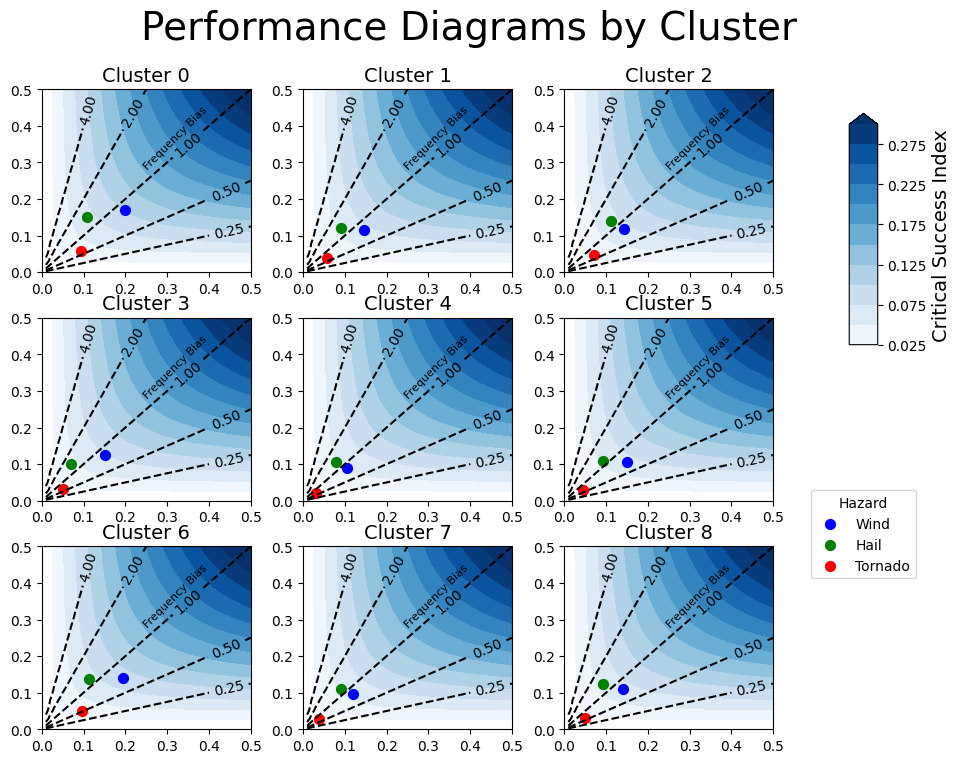

In [21]:
fig = plt.figure(figsize=(9.5, 8))

gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.82,
    top=0.88, bottom=0.08,
    wspace=0.25, hspace=0.25
)

gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle('Performance Diagrams by Cluster', fontsize=28)

axes = []
for i in range(size_1 * size_2):
    ax = fig.add_subplot(gs_maps[i // size_2, i % size_2])
    axes.append(ax)

# --- plotting ---
for i in range(n_clusters):
    d = cluster_data[i]

    csi_contour = performance_diagram(
        d['pods'],
        d['fars'],
        d['labels_skill'],
        d['colors'],
        d['markers'],
        ax=axes[i],
        title=f'Cluster {i}',
        show_cbar=False,
        show_legend=False
    )

cbar = fig.colorbar(csi_contour, cax=cax)
cbar.set_label("Critical Success Index", fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()

lax.legend(
    handles,
    labels,
    loc='center',
    frameon=True,
    title='Hazard'
)

plt.savefig('figs/clustering/performance_diagram.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig('figs/clustering/performance_diagram.png', dpi = 1000, bbox_inches='tight')

In [22]:
rows = []
for i in range(n_clusters):
    d = cluster_data[i]
    rows.append([
        i,
        d['avg_cat'],
        d['avg_wind'],
        d['avg_hail'],
        d['avg_tor'],
    ])

table = pd.DataFrame(rows, columns=[
    'Cluster',
    'Avg Category',
    'Avg Max Wind Prob',
    'Avg Max Hail Prob',
    'Avg Max Tornado Prob'
])

table

,Cluster,Avg Category,Avg Max Wind Prob,Avg Max Hail Prob,Avg Max Tornado Prob
0,0,2.507788,0.214486,0.185514,0.066293
1,1,2.205036,0.180755,0.162950,0.040072
2,2,2.329508,0.196066,0.202951,0.050869
3,3,2.121019,0.178344,0.107325,0.039045
4,4,2.086957,0.168841,0.159783,0.032029
5,5,2.178641,0.188252,0.173495,0.033379
6,6,2.257919,0.188914,0.147285,0.046335
7,7,2.163823,0.180546,0.191638,0.036894
8,8,2.289444,0.197957,0.193360,0.039240


In [21]:
# look at model perfromance for each cluster

model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
results = xr.open_dataset(f'results/predictions_losses/{model_spec}/predictions.nc')

In [22]:
results['cluster'] = (('time'), labels_cluster)

In [25]:
# for each cluster, calculate NLL, baseline NLL, llr, KL(?). Good product could be 9x9 heatmap for each of these

from scipy.stats import chi2

# variables to aggregate
base = results[['nll_pred', 'nll_baseline', 'llr_vals', 'kl_vals', 'mu', 'sigma', 'gamma', 'tau']]

# mean metrics per cluster/target
cluster_means = (
    base
    .groupby(results.cluster)
    .mean(dim='time')
    .rename({'cluster': 'cluster_id'})
)

# number of days in each cluster
Nc = results['cluster'].groupby(results.cluster).count()
Nc = Nc.rename({'cluster': 'cluster_id'})  # (cluster_id,)

# broadcast Nc to (cluster_id, target)
Nc2d = Nc.expand_dims(target=cluster_means.target)

# Λ = 2 * N_c * LLR
Lambda = 2.0 * Nc2d * cluster_means['llr_vals']
Lambda.name = 'lambda_stat'

# optional: chi-square p-value (using k=4 as discussed)
k = 4
pval = xr.apply_ufunc(lambda x: chi2.sf(x, k), Lambda)
pval.name = 'p_value'

# add to dataset
cluster_means = xr.merge([cluster_means, Lambda, pval])

lr_values = (np.exp(cluster_means['llr_vals']) - 1)
lr_values.name = 'likelihood_improvement'

cluster_means = xr.merge([cluster_means, lr_values])

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


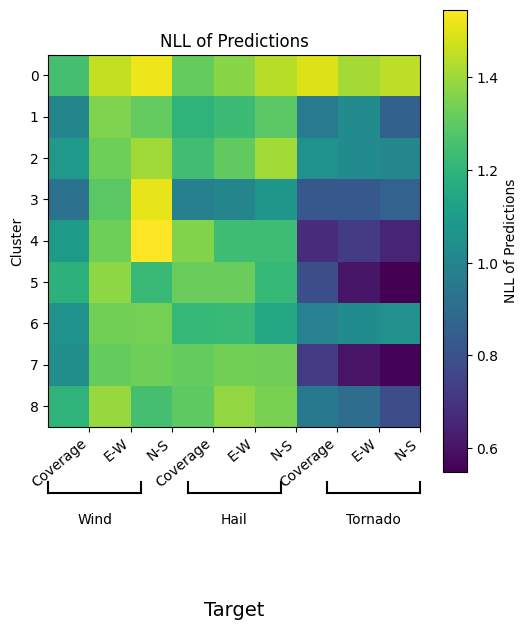

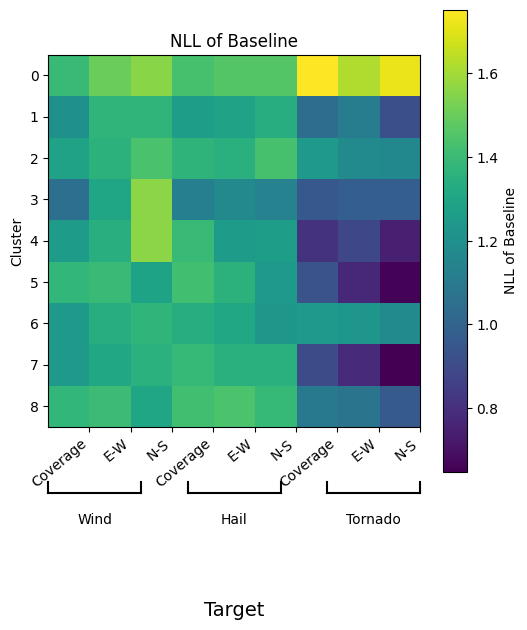

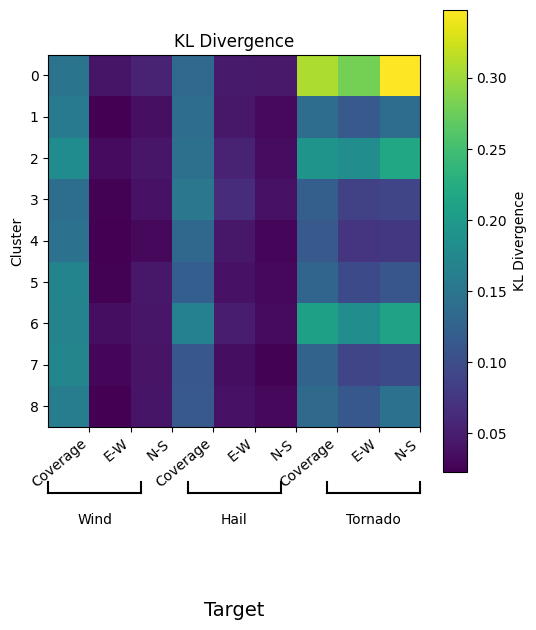

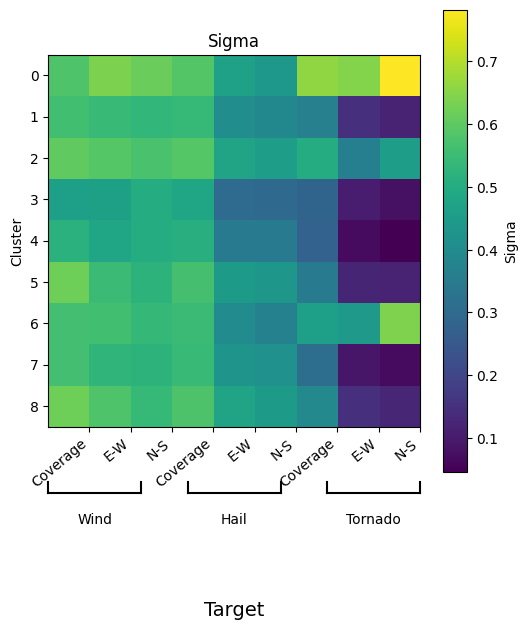

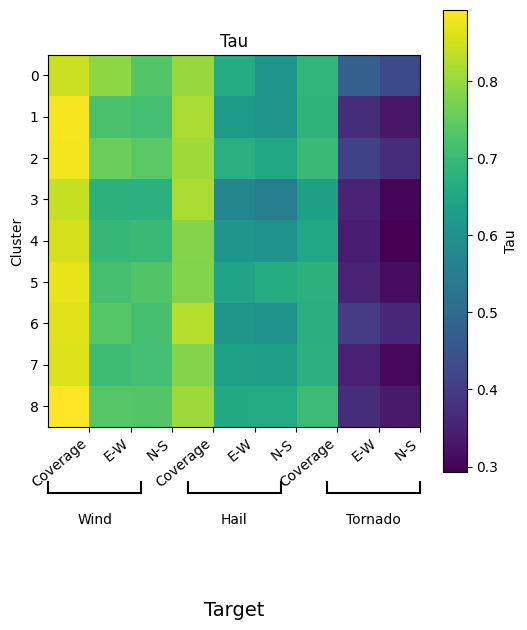

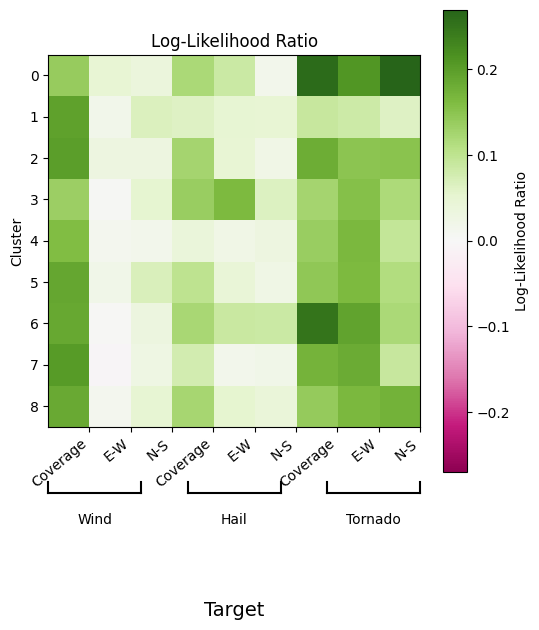

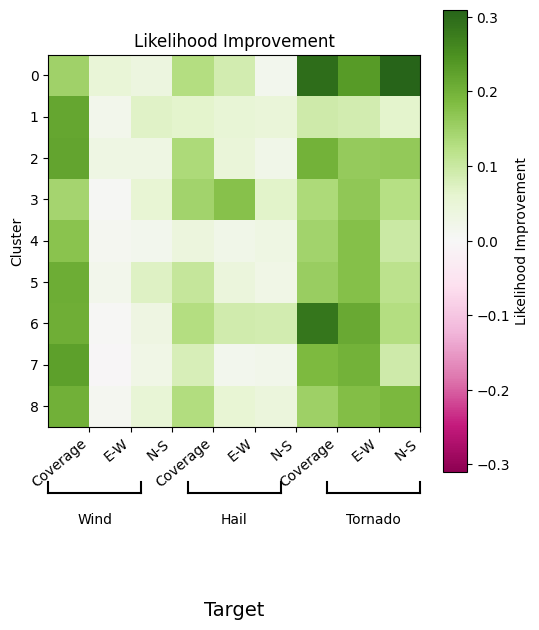

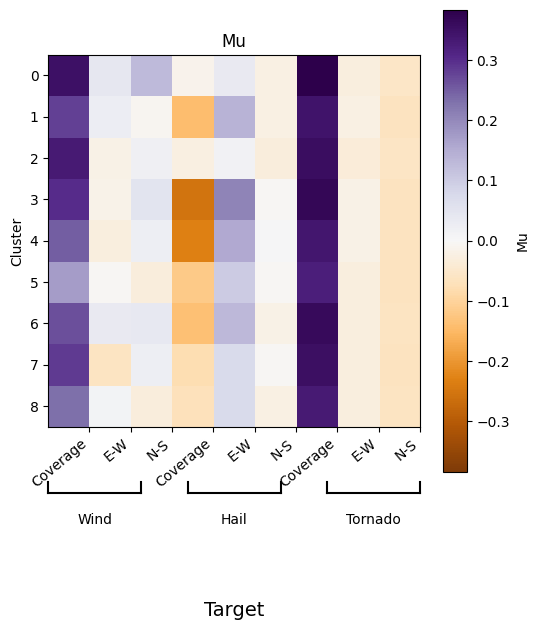

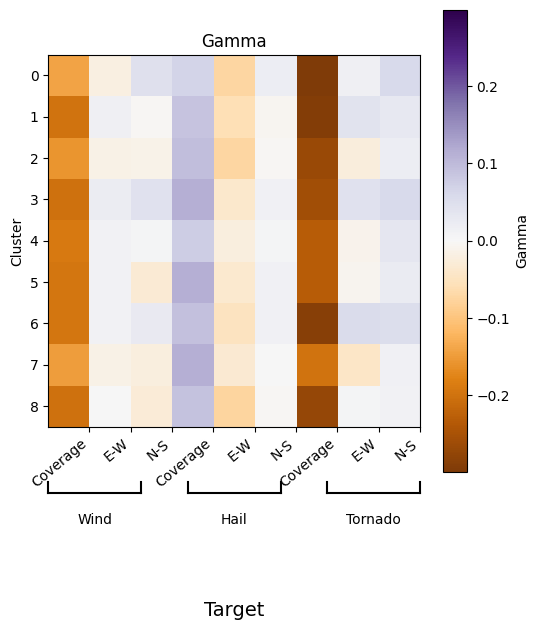

In [26]:
vars_seq = ['nll_pred', 'nll_baseline', 'kl_vals', 'sigma', 'tau']  # sequential
var_div = ['llr_vals', 'likelihood_improvement', 'mu', 'gamma']                       # diverging

name_dict = {
     'nll_pred': 'NLL of Predictions',
     'nll_baseline': 'NLL of Baseline',
     'kl_vals': 'KL Divergence',
     'sigma': 'Sigma',
     'tau': 'Tau',
     'llr_vals': 'Log-Likelihood Ratio',
     'likelihood_improvement': 'Likelihood Improvement',
     'mu': 'Mu',
     'gamma': 'Gamma',
}


def format_target_axis(ax):
    # --- inner labels ---
    inner = ['Coverage', 'E-W', 'N-S'] * 3
    ax.set_xticks(np.arange(0.5, 9.5, 1))
    ax.set_xticklabels(['Coverage', 'E-W', 'N-S'] * 3, rotation=40, ha='right')

    # --- remove any secondary axis artifacts ---
    # (important: avoids duplicate hazard labels)
    for child in ax.get_children():
        if isinstance(child, plt.SecondaryAxis if hasattr(plt, "SecondaryAxis") else type(None)):
            pass

    # --- main xlabel (only place "Target" appears) ---
    ax.set_xlabel('Target', fontsize=14, labelpad=80)

    # --- bracket groups (manual, black only) ---
    y = -0.18
    groups = [(0, 2), (3, 5), (6, 8)]
    labels = ['Wind', 'Hail', 'Tornado']

    for (x0, x1), lab in zip(groups, labels):
        x0f, x1f = x0 / 8, x1 / 8

        ax.plot([x0f, x1f], [y, y],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.plot([x0f, x0f], [y, y + 0.03],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.plot([x1f, x1f], [y, y + 0.03],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.text((x0f + x1f) / 2, y - 0.05, lab,
                transform=ax.transAxes,
                ha='center', va='top', color='black')
        

# --- sequential colormap plots ---
for v in vars_seq:
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cluster_means[v], aspect='equal')
    fig.colorbar(im, ax=ax, label=name_dict[v])

    ax.set_xlabel('Target')
    ax.set_ylabel('Cluster')
    ax.set_yticks(range(size_1 * size_2))
    ax.set_title(name_dict[v])

    format_target_axis(ax)
    plt.savefig(f'figs/clustering/heatmaps/{v}.pdf', dpi = 1000, bbox_inches='tight')
    plt.savefig(f'figs/clustering/heatmaps/{v}.png', dpi = 1000, bbox_inches='tight')
    plt.show()

for v in var_div:
        # --- diverging for llr ---
        llr = cluster_means[v]
        vmax = abs(llr).max().item()

        fig, ax = plt.subplots(figsize=(6, 6))
        if v in ['llr_vals', 'likelihood_improvement']:
             cmap = 'PiYG'
        else:
             cmap = 'PuOr'
        im = ax.imshow(llr, aspect='equal', vmin=-vmax, vmax=vmax, cmap=cmap)
        fig.colorbar(im, ax=ax, label=name_dict[v])

        ax.set_xlabel('Target')
        ax.set_ylabel('Cluster')
        ax.set_yticks(range(size_1 * size_2))
        ax.set_title(name_dict[v])

        format_target_axis(ax)
        plt.savefig(f'figs/clustering/heatmaps/{v}.pdf', dpi = 1000, bbox_inches='tight')
        plt.savefig(f'figs/clustering/heatmaps/{v}.png', dpi = 1000, bbox_inches='tight')
        plt.show()

In [23]:
mu_mean = (
    results['mu']
    .groupby(results['cluster'])
    .mean('time')
    .sortby('cluster')
)

truth_mean = (
    results['truth']
    .groupby(results['cluster'])
    .mean('time')
    .sortby('cluster')
)

bias_mean = (
    (results['mu'] - results['truth'])
    .groupby(results['cluster'])
    .mean('time')
    .sortby('cluster')
)

sharp_mean = (
    results['sigma']
    .groupby(results['cluster'])
    .mean('time')
    .sortby('cluster')
)

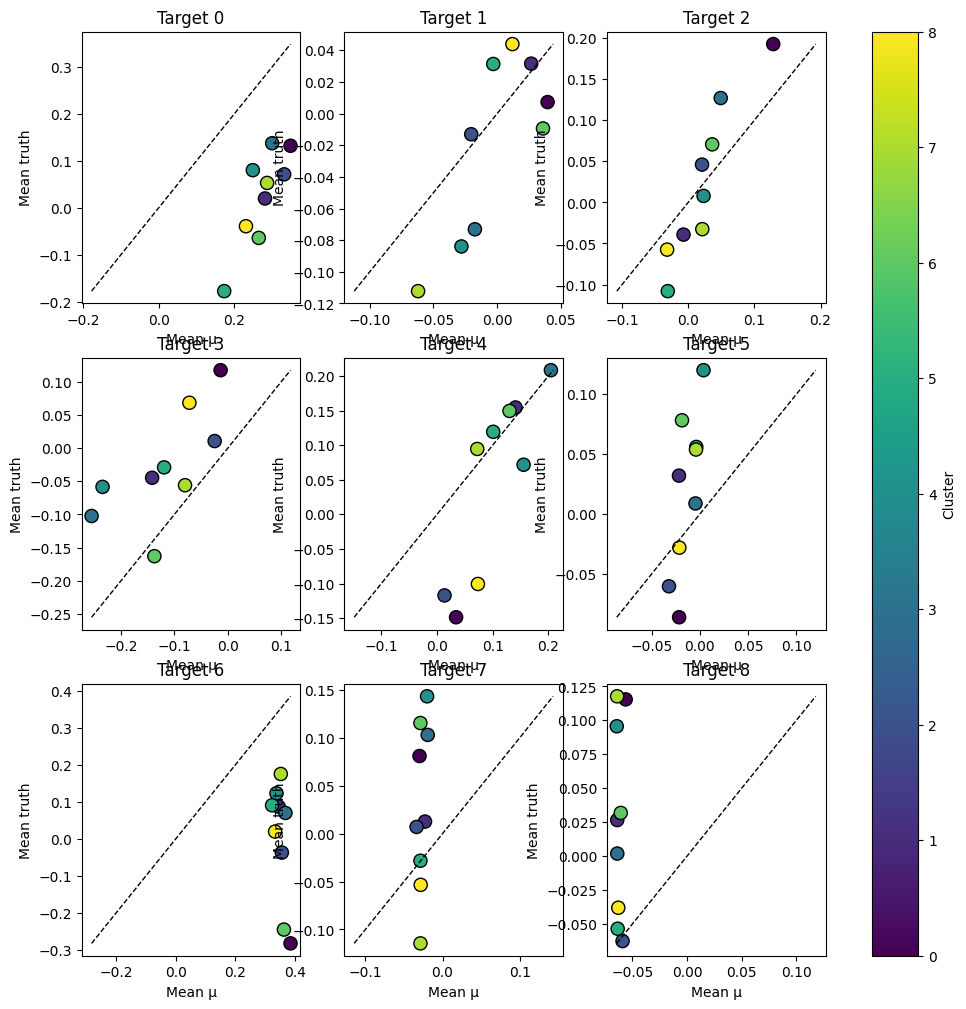

In [24]:
clusters = mu_mean['cluster'].values
norm = plt.Normalize(clusters.min(), clusters.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for t in mu_mean['target'].values:
    ax = axes[t]

    x = mu_mean.sel(target=t).values      # 9 clusters
    y = truth_mean.sel(target=t).values

    sc = ax.scatter(
        x, y,
        c=clusters,
        cmap=cmap,
        norm=norm,
        s=90,
        edgecolor='k'
    )

    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)

    ax.set_title(f'Target {t}')
    ax.set_xlabel('Mean μ')
    ax.set_ylabel('Mean truth')

cbar = fig.colorbar(sc, ax=axes.tolist(), label='Cluster')
#plt.tight_layout()

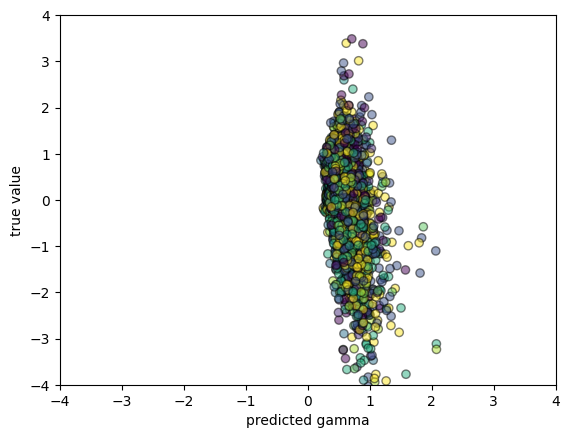

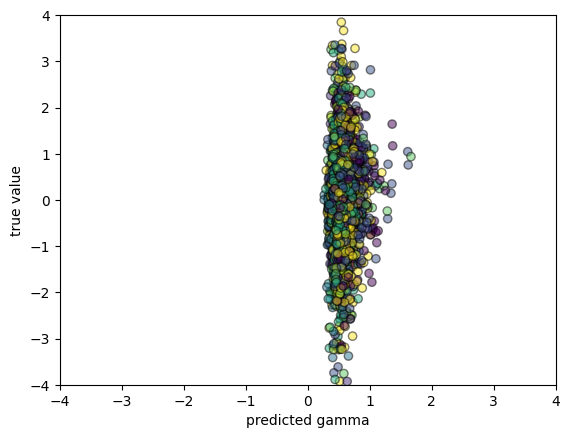

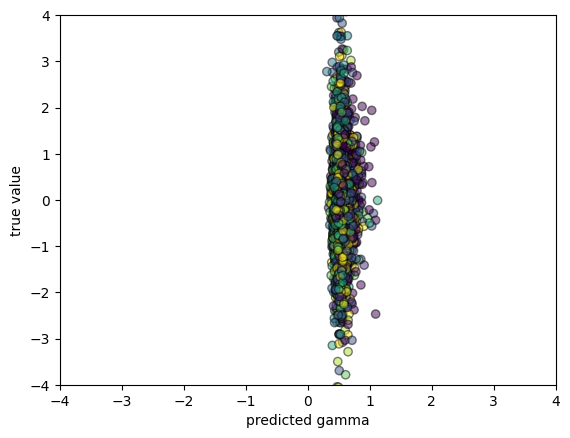

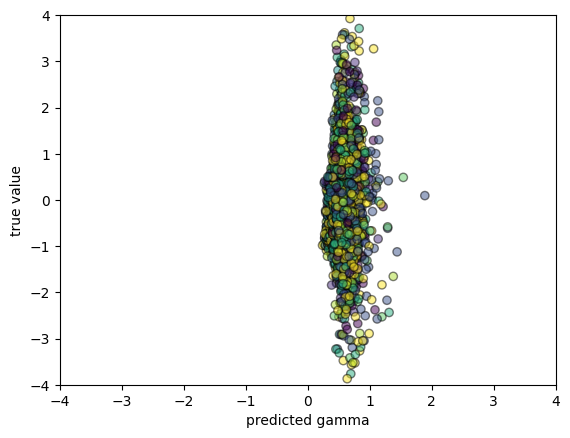

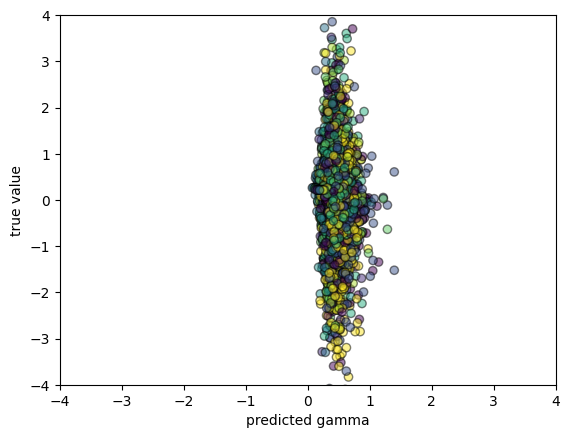

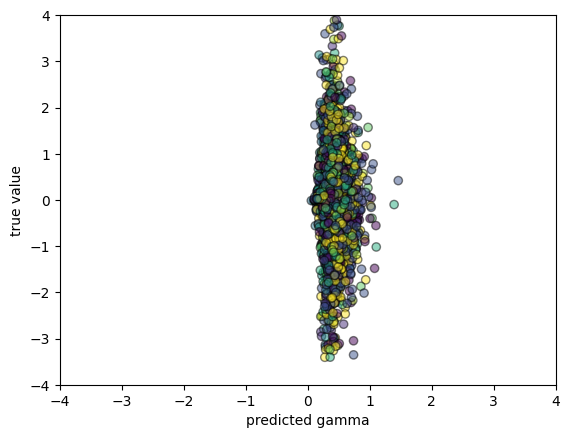

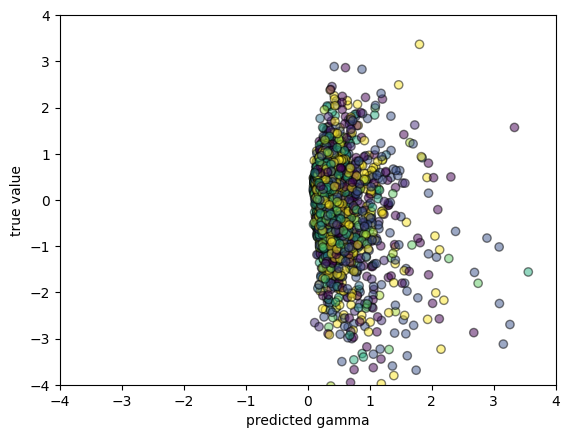

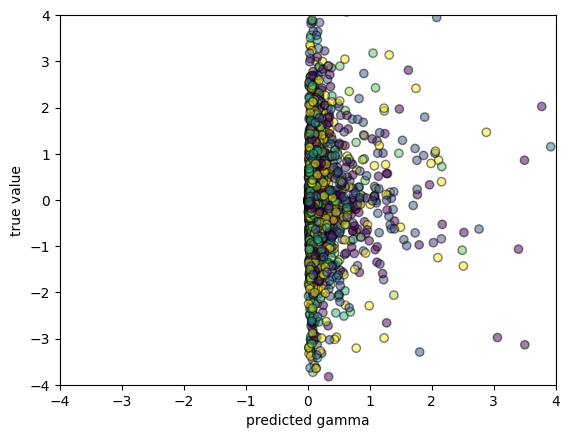

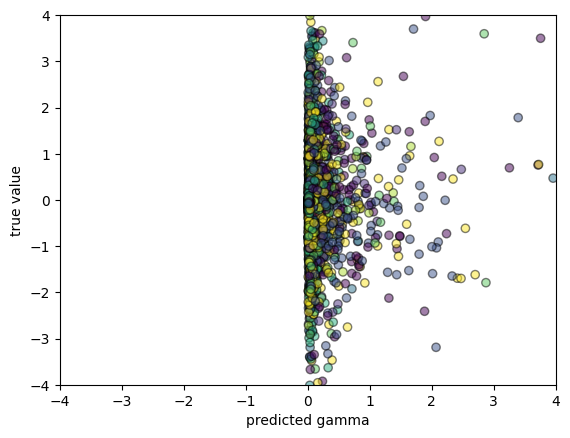

<Figure size 640x480 with 0 Axes>

In [31]:
for target in results['target']:
    plt.scatter(
        results['sigma'].sel(target=target),
        results['truth'].sel(target=target),
        c=results['cluster'],
        cmap='viridis',
        alpha=0.5,
        edgecolor='k'
    )
    #plt.axline((0, 0), slope=1, color='red', linestyle='--')
    plt.xlabel('predicted gamma')
    plt.ylabel('true value')
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.show()
    plt.clf()

In [29]:
results.groupby('cluster').mean('time')

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


<xarray.Dataset>
Dimensions:       (cluster: 9, target: 9)
Coordinates:
  * target        (target) int64 0 1 2 3 4 5 6 7 8
  * cluster       (cluster) int64 0 1 2 3 4 5 6 7 8
Data variables:
    mu            (cluster, target) float32 0.3495 0.03959 ... -0.02835 -0.063
    sigma         (cluster, target) float32 0.58 0.6361 0.6142 ... 0.1491 0.1238
    gamma         (cluster, target) float32 -0.1413 -0.01934 ... 0.01147
    tau           (cluster, target) float32 0.843 0.7909 0.7329 ... 0.3725 0.337
    truth         (cluster, target) float32 0.1325 0.007279 ... -0.03812
    nll_pred      (cluster, target) float32 1.253 1.456 1.521 ... 0.9057 0.7862
    nll_baseline  (cluster, target) float32 1.391 1.504 1.558 ... 1.071 0.9601
    llr_vals      (cluster, target) float32 0.1382 0.04807 ... 0.1656 0.174
    kl_vals       (cluster, target) float32 0.1472 0.04151 ... 0.1126 0.1445